# Importación de las librerías necesarias para la ejecución #

In [42]:
#Librerias Necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense
from keras import backend as K

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
#from sklearn.preprocessing import scale

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix

# Lectura de los datos de los partidos ya formateados en .csv

In [43]:
# Lista para almacenar los DataFrames leídos
dataframes = []

# Leer los archivos CSV que contienen los DataFrames
archivos = ['SP1-1011.csv','SP1-1112.csv','SP1-1213.csv','SP1-1314.csv','SP1-1415.csv','SP1-1516.csv','SP1-1617.csv', 'SP1-1718.csv',
            'SP1-1819.csv', 'SP1-1920.csv', 'SP1-2021.csv', 'SP1-2122.csv', 
            'SP1-2223.csv', 'SP1-2324.csv']

#archivos = ['SP1-1920.csv', 'SP1-2021.csv', 'SP1-2122.csv', 
#            'SP1-2223.csv', 'SP1-2324.csv']

archivos_segunda = ['SP2-1920.csv', 
            'SP2-2021.csv', 'SP2-2122.csv', 'SP2-2223.csv', 'SP2-2324.csv']

#archivos += archivos_segunda

for archivo in archivos:
    # Leer el archivo y almacenar el DataFrame en la lista
    df = pd.read_csv("Datos_Formateados/"+archivo)
    dataframes.append(df)

# Concatenar todos los DataFrames en uno solo
datos_partidos = pd.concat(dataframes, ignore_index=True)
datos_partidos.shape

(5229, 17)

In [44]:
datos_partidos = datos_partidos.dropna()
datos_partidos.shape

(5229, 17)

In [45]:
datos_partidos.head()

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HY,AY,HR,AR,FTR
0,SP1,28/08/10,Hercules,Ath Bilbao,0,1,0,0,9,14,3,5,2,4,1,0,A
1,SP1,28/08/10,Levante,Sevilla,1,4,1,2,7,14,4,8,4,4,0,0,A
2,SP1,28/08/10,Malaga,Valencia,1,3,1,1,19,21,5,8,2,5,0,0,A
3,SP1,29/08/10,Espanol,Getafe,3,1,1,0,17,13,8,1,3,4,0,0,H
4,SP1,29/08/10,La Coruna,Zaragoza,0,0,0,0,8,8,2,3,0,1,0,0,D


In [46]:
def get_equipos(dataframe: pd.DataFrame) -> list:
    list = []
    for idx in dataframe.index:
        if dataframe['HomeTeam'][idx] not in list:
            list.append(dataframe['HomeTeam'][idx])
        if dataframe['AwayTeam'][idx] not in list:
            list.append(dataframe['AwayTeam'][idx])
    return list

equipos = get_equipos(dataframe=datos_partidos)
equipos

['Hercules',
 'Ath Bilbao',
 'Levante',
 'Sevilla',
 'Malaga',
 'Valencia',
 'Espanol',
 'Getafe',
 'La Coruna',
 'Zaragoza',
 'Mallorca',
 'Real Madrid',
 'Osasuna',
 'Almeria',
 'Santander',
 'Barcelona',
 'Sociedad',
 'Villarreal',
 'Ath Madrid',
 'Sp Gijon',
 'Granada',
 'Betis',
 'Vallecano',
 'Celta',
 'Valladolid',
 'Elche',
 'Eibar',
 'Cordoba',
 'Las Palmas',
 'Alaves',
 'Leganes',
 'Girona',
 'Huesca',
 'Cadiz']

# Predicción del ganador de un partido 

## - Pre-procesamiento de los datos ##

### Limpiado de valores de la columna FTR diferentes a [A,D,H]

In [47]:
condicion = (datos_partidos['FTR'] != 'A') & (datos_partidos['FTR'] != 'H') & (datos_partidos['FTR'] != 'D')
datos_partidos = datos_partidos.drop(datos_partidos[condicion].index)

### Obtención del gol average medio de cada partido

In [48]:
def get_goles_marcados_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_goles_por_partido = []
    partidos_del_equipo = dataframe.loc[(dataframe['HomeTeam'] == equipo) | (dataframe['AwayTeam'] == equipo)]
    for idx, partido in partidos_del_equipo.iterrows():
        if partido['HomeTeam'] == equipo:
            lista_goles_por_partido.append(partido['FTHG'])
        if partido['AwayTeam'] == equipo:
            lista_goles_por_partido.append(partido['FTAG'])
    return lista_goles_por_partido

def get_goles_encajados_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_goles_por_partido = []
    partidos_del_equipo = dataframe.loc[(dataframe['HomeTeam'] == equipo) | (dataframe['AwayTeam'] == equipo)]
    for idx, partido in partidos_del_equipo.iterrows():
        if partido['HomeTeam'] == equipo:
            lista_goles_por_partido.append(partido['FTAG'])
        if partido['AwayTeam'] == equipo:
            lista_goles_por_partido.append(partido['FTHG'])
    return lista_goles_por_partido

def get_media_goles_marcados_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_goles_por_partido = get_goles_marcados_por_partido(dataframe=dataframe, equipo=equipo)
    lista_media_goles_por_partido = []
    goles_acumulados = 0
    for idx, valor in enumerate(lista_goles_por_partido):
        lista_media_goles_por_partido.append((valor + goles_acumulados) / (idx+1))
        goles_acumulados += valor
    return lista_media_goles_por_partido

def get_media_goles_encajados_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_goles_por_partido = get_goles_encajados_por_partido(dataframe=dataframe, equipo=equipo)
    lista_media_goles_por_partido = []
    goles_acumulados = 0
    # añadir que si ve que el año de la temporada es distinto a uno previo goles acumulados = 0 para que cada temporada se reinicie
    for idx, valor in enumerate(lista_goles_por_partido):
        lista_media_goles_por_partido.append((valor + goles_acumulados) / (idx+1))
        goles_acumulados += valor
    return lista_media_goles_por_partido

def get_media_gol_average_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_goles_marcados_por_partido = get_goles_marcados_por_partido(dataframe=dataframe, equipo=equipo)
    lista_goles_encajados_por_partido = get_goles_encajados_por_partido(dataframe=dataframe, equipo=equipo)
    lista_media_gol_average_por_partido = []
    valor_acumulado = 0
    for idx, valor in enumerate(lista_goles_marcados_por_partido):
        lista_media_gol_average_por_partido.append((valor - lista_goles_encajados_por_partido[idx] + valor_acumulado) / (idx+1))
        valor_acumulado += (valor - lista_goles_encajados_por_partido[idx])
    return lista_media_gol_average_por_partido

def obtencion_gol_average_dataframe(dataframe: pd.DataFrame, guardar: bool) -> list:
    lista_listas_gol_average_medio_cada_equipo = []
    equipos = get_equipos(dataframe=dataframe)
    for equipo in equipos:
        lista_gol_average_medio_un_equipo = get_media_gol_average_por_partido(dataframe=dataframe, equipo=equipo)
        lista_gol_average_medio_un_equipo.insert(0,0)
        if guardar:
            dict_ultimo_gol_average_equipo[equipo] = lista_gol_average_medio_un_equipo[-1]
        lista_gol_average_medio_un_equipo.pop()
        lista_listas_gol_average_medio_cada_equipo.append(lista_gol_average_medio_un_equipo)
    return lista_listas_gol_average_medio_cada_equipo
        
def get_diferencia_media_gol_average_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_media_gol_average_por_partido = get_media_gol_average_por_partido(dataframe=dataframe, equipo=equipo)
    lista_diferencias = []
    valor_anterior = 0
    for valor in lista_media_gol_average_por_partido:
        lista_diferencias.append(valor - valor_anterior)
        valor_anterior = valor
    return lista_diferencias

def obtencion_diferencias_average_dataframe(dataframe: pd.DataFrame, guardar: bool) -> list:
    lista_listas_diferencias_gol_average_medio_cada_equipo = []
    equipos = get_equipos(dataframe=dataframe)
    for equipo in equipos:
        lista_diferencias_gol_average_medio_un_equipo = get_diferencia_media_gol_average_por_partido(dataframe=dataframe, equipo=equipo)
        lista_diferencias_gol_average_medio_un_equipo.insert(0,0)
        if guardar:
            dict_ultimas_diferencias_cada_equipo[equipo] = lista_diferencias_gol_average_medio_un_equipo[-1]
        lista_diferencias_gol_average_medio_un_equipo.pop()
        lista_listas_diferencias_gol_average_medio_cada_equipo.append(lista_diferencias_gol_average_medio_un_equipo)
    return lista_listas_diferencias_gol_average_medio_cada_equipo
        
def get_tarjetas_rojas_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_rojas_por_partido = []
    partidos_del_equipo = dataframe.loc[(dataframe['HomeTeam'] == equipo) | (dataframe['AwayTeam'] == equipo)]
    for idx, partido in partidos_del_equipo.iterrows():
        if partido['HomeTeam'] == equipo:
            lista_rojas_por_partido.append(partido['HR'])
        if partido['AwayTeam'] == equipo:
            lista_rojas_por_partido.append(partido['AR'])
    return lista_rojas_por_partido

def get_media_rojas_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_tarjetas_rojas_por_partido = get_tarjetas_rojas_por_partido(dataframe=dataframe, equipo=equipo)
    lista_media_tarjetas_rojas_por_partido = []
    valor_acumulado = 0
    for idx, valor in enumerate(lista_tarjetas_rojas_por_partido):
        lista_media_tarjetas_rojas_por_partido.append((valor + valor_acumulado) / (idx+1))
        valor_acumulado += valor
    return lista_media_tarjetas_rojas_por_partido

def obtencion_rojas_average_dataframe(dataframe: pd.DataFrame, guardar: bool) -> list:
    lista_listas_rojas_por_partido_cada_equipo = []
    equipos = get_equipos(dataframe=dataframe)
    for equipo in equipos:
        lista_rojas_por_partido_un_equipo = get_media_rojas_por_partido(dataframe=dataframe, equipo=equipo)
        lista_rojas_por_partido_un_equipo.insert(0,0)
        if guardar:
            dict_ultimas_rojas_cada_equipo[equipo] = lista_rojas_por_partido_un_equipo[-1]
        lista_rojas_por_partido_un_equipo.pop()
        lista_listas_rojas_por_partido_cada_equipo.append(lista_rojas_por_partido_un_equipo)
    return lista_listas_rojas_por_partido_cada_equipo

def get_puntos_en_liga_equipo(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_puntos_por_partido = []
    puntos = 0
    partidos_equipo = dataframe.loc[(dataframe['HomeTeam'] == equipo) | (dataframe['AwayTeam'] == equipo)]
    for idx, partido in partidos_equipo.iterrows():
        resultado = partido['FTR']
        if partido['HomeTeam'] == equipo and resultado == 'H':
           puntos += 3 
        elif partido['AwayTeam'] == equipo and resultado == 'A':
           puntos += 3
        elif resultado == 'D':
           puntos += 1
        else:
            puntos += 0
        lista_puntos_por_partido.append(puntos)
    return lista_puntos_por_partido

def obtencion_puntos_en_liga(dataframe: pd.DataFrame, guardar:bool) -> list:
    lista_listas_puntos_en_liga = []
    equipos = get_equipos(dataframe=dataframe)
    for equipo in equipos:
        lista_puntos_por_partido_un_equipo = get_puntos_en_liga_equipo(dataframe=dataframe, equipo=equipo)
        lista_puntos_por_partido_un_equipo.insert(0,0)
        if guardar:
            dict_ultimos_puntos_cada_equipo[equipo] = lista_puntos_por_partido_un_equipo[-1]
        lista_puntos_por_partido_un_equipo.pop()
        lista_listas_puntos_en_liga.append(lista_puntos_por_partido_un_equipo)
    return lista_listas_puntos_en_liga
    
def obtencion_media_goles_marcados(dataframe: pd.DataFrame, guardar:bool) -> list:
    lista_listas_goles_marcados = []
    equipos = get_equipos(dataframe=dataframe)
    for equipo in equipos:
        lista_goles_por_partido_un_equipo = get_media_goles_marcados_por_partido(dataframe=dataframe, equipo=equipo)
        lista_goles_por_partido_un_equipo.insert(0,0)
        if guardar:
            dict_ultimos_goles_marcados_cada_equipo[equipo] = lista_goles_por_partido_un_equipo[-1]
        lista_goles_por_partido_un_equipo.pop()
        lista_listas_goles_marcados.append(lista_goles_por_partido_un_equipo)
    return lista_listas_goles_marcados
    
def insercion_datos_cada_dataframe(dataframe: pd.DataFrame, lista_listas_gol_average_medio_cada_equipo: list, lista_listas_diferencias_gol_average_medio_cada_equipo: list,
lista_listas_rojas_por_partido_cada_equipo: list, lista_listas_puntos_por_partido: list, lista_listas_goles_marcados_por_partido: list):
    equipos = get_equipos(dataframe=dataframe)
    for idx_equipos,equipo in enumerate(equipos):
        partidos_del_equipo = dataframe.loc[(dataframe['HomeTeam'] == equipo) | (dataframe['AwayTeam'] == equipo)]
        idx_partidos = 0
        for idx, partido in partidos_del_equipo.iterrows():
            if partido['HomeTeam'] == equipo:
                dataframe.at[idx,'Gol_Average_Home'] = lista_listas_gol_average_medio_cada_equipo[idx_equipos][idx_partidos]
                dataframe.at[idx,'Dif_Home'] = lista_listas_diferencias_gol_average_medio_cada_equipo[idx_equipos][idx_partidos]
                dataframe.at[idx,'Rojas_Home'] = lista_listas_rojas_por_partido_cada_equipo[idx_equipos][idx_partidos]
                dataframe.at[idx,'Puntos_Home'] = lista_listas_puntos_por_partido[idx_equipos][idx_partidos]
                dataframe.at[idx,'Goles_Marcados_Home'] = lista_listas_goles_marcados_por_partido[idx_equipos][idx_partidos]
            if partido['AwayTeam'] == equipo:
                dataframe.at[idx,'Gol_Average_Away'] = lista_listas_gol_average_medio_cada_equipo[idx_equipos][idx_partidos]
                dataframe.at[idx,'Dif_Away'] = lista_listas_diferencias_gol_average_medio_cada_equipo[idx_equipos][idx_partidos]
                dataframe.at[idx,'Rojas_Away'] = lista_listas_rojas_por_partido_cada_equipo[idx_equipos][idx_partidos]
                dataframe.at[idx,'Puntos_Away'] = lista_listas_puntos_por_partido[idx_equipos][idx_partidos]
                dataframe.at[idx,'Goles_Marcados_Away'] = lista_listas_goles_marcados_por_partido[idx_equipos][idx_partidos]
            idx_partidos += 1
    return dataframe    
    
dict_ultimas_diferencias_cada_equipo = {}    
dict_ultimo_gol_average_equipo = {}
dict_ultimas_rojas_cada_equipo = {}
dict_ultimos_puntos_cada_equipo = {}
dict_ultimos_goles_marcados_cada_equipo = {}
guardar=False
for idx,temporada in enumerate(dataframes):
    if idx == (len(dataframes) - 1):
        guardar = True
    lista_listas_gol_average_medio_cada_equipo = obtencion_gol_average_dataframe(dataframe=temporada, guardar=guardar)
    lista_listas_diferencias_gol_average_medio_cada_equipo = obtencion_diferencias_average_dataframe(dataframe=temporada, guardar=guardar)
    lista_media_tarjetas_rojas_por_partido = obtencion_rojas_average_dataframe(dataframe=temporada, guardar=guardar)
    lista_listas_puntos_por_partido = obtencion_puntos_en_liga(dataframe=temporada, guardar=guardar)
    lista_listas_goles_marcados_por_partido = obtencion_media_goles_marcados(dataframe=temporada, guardar=guardar)

    dataframe_con_datos_temporada = insercion_datos_cada_dataframe(dataframe=temporada, lista_listas_gol_average_medio_cada_equipo=lista_listas_gol_average_medio_cada_equipo,
                lista_listas_diferencias_gol_average_medio_cada_equipo=lista_listas_diferencias_gol_average_medio_cada_equipo,
                lista_listas_rojas_por_partido_cada_equipo=lista_media_tarjetas_rojas_por_partido,
                lista_listas_puntos_por_partido=lista_listas_puntos_por_partido,
                lista_listas_goles_marcados_por_partido=lista_listas_goles_marcados_por_partido)
    dataframes[idx] = dataframe_con_datos_temporada
    dataframe_con_datos_temporada.to_csv("ayno.csv")
    
datos_partidos = pd.concat(dataframes)
    
print(dict_ultimos_goles_marcados_cada_equipo)
print(len(dict_ultimos_goles_marcados_cada_equipo))

{'Almeria': 0.9655172413793104, 'Vallecano': 0.8620689655172413, 'Sevilla': 1.2413793103448276, 'Valencia': 1.1428571428571428, 'Sociedad': 1.4482758620689655, 'Girona': 2.0344827586206895, 'Las Palmas': 1.0, 'Mallorca': 0.8620689655172413, 'Ath Bilbao': 1.7241379310344827, 'Real Madrid': 2.206896551724138, 'Celta': 1.103448275862069, 'Osasuna': 1.1379310344827587, 'Villarreal': 1.6206896551724137, 'Betis': 1.1724137931034482, 'Getafe': 1.2758620689655173, 'Barcelona': 2.0689655172413794, 'Cadiz': 0.6896551724137931, 'Alaves': 0.896551724137931, 'Ath Madrid': 1.8620689655172413, 'Granada': 1.0714285714285714}
20


### Asignación de etiquetas numéricas a los posibles valores de FTR, HomeTeam y AwayTeam

In [49]:
lb_make = LabelEncoder()
datos_partidos['target FTR'] = lb_make.fit_transform(datos_partidos['FTR'])
datos_partidos['FTR'].value_counts()
label_encoder = LabelEncoder()
datos_partidos['labeled Home'] = label_encoder.fit_transform(datos_partidos['HomeTeam'])
datos_partidos['labeled Away'] = label_encoder.fit_transform(datos_partidos['AwayTeam'])

In [50]:
datos_partidos['FTR'].value_counts()

FTR
H    2443
A    1475
D    1311
Name: count, dtype: int64

In [51]:
datos_partidos['target FTR'].value_counts()

target FTR
2    2443
0    1475
1    1311
Name: count, dtype: int64

In [52]:

datos_locales = datos_partidos.loc[datos_partidos['FTR'] == 'H']  # Obtiene los índices de las primeras 100 filas que cumplen la condición
datos_empates = datos_partidos.loc[datos_partidos['FTR'] == 'D']  # Obtiene los índices de las primeras 100 filas que cumplen la condición
datos_visitantes = datos_partidos.loc[datos_partidos['FTR'] == 'A']  # Obtiene los índices de las primeras 100 filas que cumplen la condición
print(len(datos_locales))
print(len(datos_empates))
print(len(datos_visitantes))

dataframes = [datos_empates, datos_visitantes.head(1350), datos_locales.head(1380)]
datos_partidos = pd.concat(dataframes)
datos_partidos = datos_partidos.drop_duplicates()
datos_partidos['FTR'].value_counts()


2443
1311
1475


FTR
H    1380
A    1350
D    1311
Name: count, dtype: int64

### Dividir el dataframe en 2 para coger empates y visitantes de uno

In [12]:
'''
mitad = len(datos_partidos) // 2

datos_partidos_empates_visitantes = datos_partidos.iloc[:mitad]
datos_partidos = datos_partidos.iloc[mitad:]

datos_empates = datos_partidos_empates_visitantes[datos_partidos_empates_visitantes['FTR'] == 'D'].head(500)
datos_visitantes = datos_partidos_empates_visitantes[datos_partidos_empates_visitantes['FTR'] == 'A'].head(500)
#datos_locales = datos_partidos_empates_visitantes[datos_partidos_empates_visitantes['FTR'] == 'H'].head(200)

dataframes = [datos_partidos, datos_empates, datos_visitantes]

datos_partidos = pd.concat(dataframes)
datos_partidos = datos_partidos.drop_duplicates()

conteo_resultados = datos_partidos['FTR'].value_counts()

print(conteo_resultados)
'''

"\nmitad = len(datos_partidos) // 2\n\ndatos_partidos_empates_visitantes = datos_partidos.iloc[:mitad]\ndatos_partidos = datos_partidos.iloc[mitad:]\n\ndatos_empates = datos_partidos_empates_visitantes[datos_partidos_empates_visitantes['FTR'] == 'D'].head(500)\ndatos_visitantes = datos_partidos_empates_visitantes[datos_partidos_empates_visitantes['FTR'] == 'A'].head(500)\n#datos_locales = datos_partidos_empates_visitantes[datos_partidos_empates_visitantes['FTR'] == 'H'].head(200)\n\ndataframes = [datos_partidos, datos_empates, datos_visitantes]\n\ndatos_partidos = pd.concat(dataframes)\ndatos_partidos = datos_partidos.drop_duplicates()\n\nconteo_resultados = datos_partidos['FTR'].value_counts()\n\nprint(conteo_resultados)\n"

### Definición de los predictores y del objetivo de predicción ###
| Variable | Descripción
| :-------- | :-------:
| HomeTeam | Nombre del equipo local
| AwayTeam | Nombre del equipo visitante
| Gol_Average_Home | Gol Average medio del equipo local hasta el partido que se juega
| Gol_Average_Away | Gol Average medio del equipo visitante hasta el partido que se juega
| Dif_Home | Diferencia entre el Gol Average medio del local de los dos últimos partidos
| Dif_Away | Diferencia entre el Gol Average medio del visitante de los dos últimos partidos
| Rojas_Home | Media de rojas del equipo local
| Rojas_Away | Media de rojas del equipo visitante
| FTR | Ganador del partido (Home, Draw, Away)
| target FTR | Ganador del partido (2, 1, 0)

In [53]:
equipos_locales = datos_partidos['labeled Home']
equipos_visitantes = datos_partidos['labeled Away']
gol_average_home = datos_partidos['Gol_Average_Home']
gol_average_away = datos_partidos['Gol_Average_Away']
gol_averages = datos_partidos[['Gol_Average_Home','Gol_Average_Away']]
diferencia_home = datos_partidos['Dif_Home']
diferencia_away = datos_partidos['Dif_Away']
diferencias = datos_partidos[['Dif_Home','Dif_Away']]
rojas_home = datos_partidos['Rojas_Home']
rojas_away = datos_partidos['Rojas_Away']
rojas = datos_partidos[['Rojas_Home','Rojas_Away']]
puntos_home = datos_partidos['Puntos_Home']
puntos_away = datos_partidos['Puntos_Away']
puntos = datos_partidos[['Puntos_Home','Puntos_Away']]
goles_home = datos_partidos['Goles_Marcados_Home']
goles_away = datos_partidos['Goles_Marcados_Away']
goles = datos_partidos[['Goles_Marcados_Home','Goles_Marcados_Away']]
columnas_features = ['Gol_Average_Home','Gol_Average_Away','Dif_Home','Dif_Away','Rojas_Home','Rojas_Away']
features = datos_partidos[columnas_features]
target = datos_partidos['target FTR']

In [14]:
#target = to_categorical(target)
#target.shape

## - Normalización de los datos

Ahora mismo, los dos predictores son variables categóricas de tipo string. Estos no pueden ser alimentados directamente al modelo ya que podría ocasionar algún error. Antes deben ser procesados y convertidos a un valor númerico fácilmente interpretable por el modelo. Para lograr esto, utilizo la opción del **One-shot encoding**

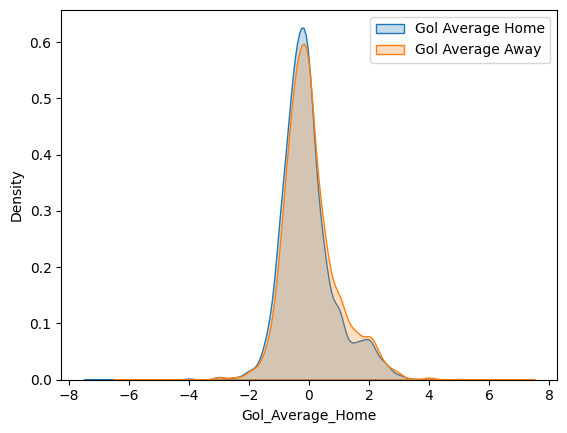

In [54]:
columnas = ['Gol Average Home','Gol Average Away']
for i, col in enumerate(gol_averages.columns):
    sns.kdeplot(gol_averages[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

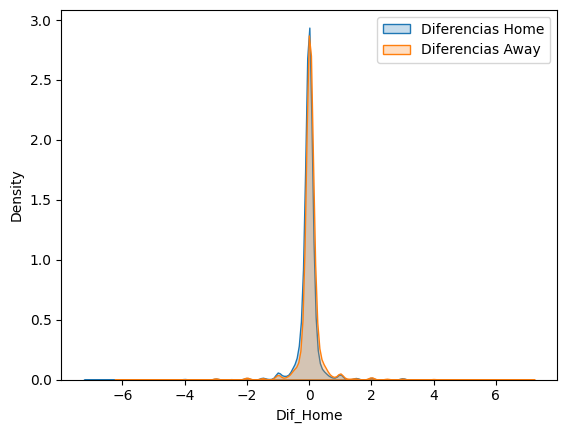

In [55]:
columnas = ['Diferencias Home','Diferencias Away']
for i, col in enumerate(diferencias.columns):
    sns.kdeplot(diferencias[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

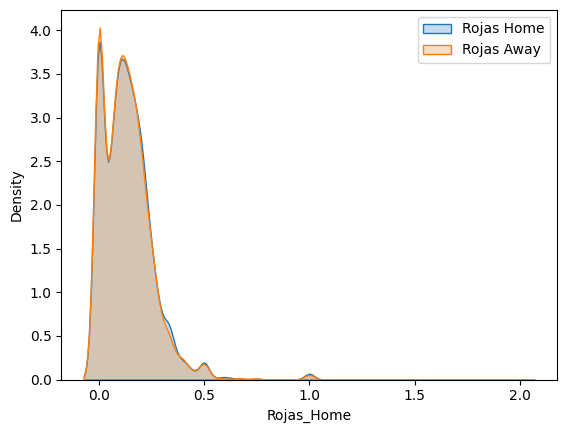

In [56]:
columnas = ['Rojas Home','Rojas Away']
for i, col in enumerate(rojas.columns):
    sns.kdeplot(rojas[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

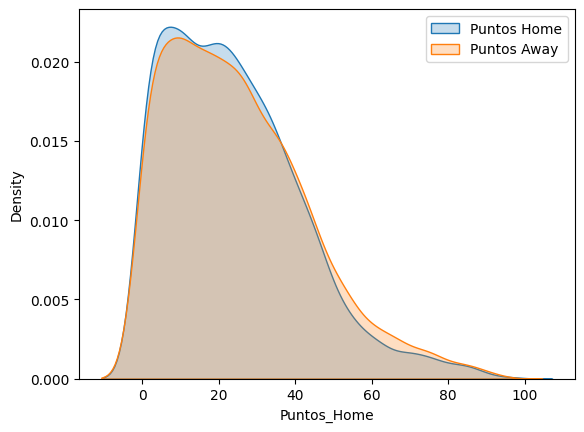

In [57]:
columnas = ['Puntos Home','Puntos Away']
for i, col in enumerate(puntos.columns):
    sns.kdeplot(puntos[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

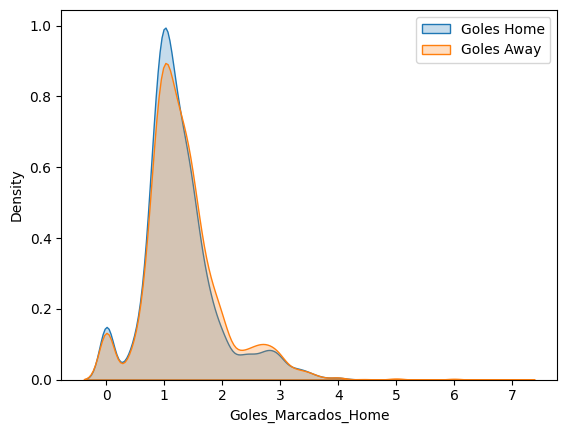

In [58]:
columnas = ['Goles Home','Goles Away']
for i, col in enumerate(goles.columns):
    sns.kdeplot(goles[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

In [59]:
scale = MinMaxScaler().fit(features)
features_normalized = scale.transform(features)
features_normalized_dataframe = pd.DataFrame(features_normalized, columns=columnas_features)
features_normalized_dataframe.head()

,Gol_Average_Home,Gol_Average_Away,Dif_Home,Dif_Away,Rojas_Home,Rojas_Away,Goles_Marcados_Home,Goles_Marcados_Away,Puntos_Home,Puntos_Away
0,0.538462,0.461538,0.538462,0.461538,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
1,0.538462,0.461538,0.538462,0.461538,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
2,0.538462,0.461538,0.538462,0.461538,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
3,0.769231,0.461538,0.769231,0.461538,0.000000,0.0,0.666667,0.000000,0.030928,0.010638
4,0.538462,0.538462,0.538462,0.538462,0.666667,0.0,0.000000,0.142857,0.010309,0.031915


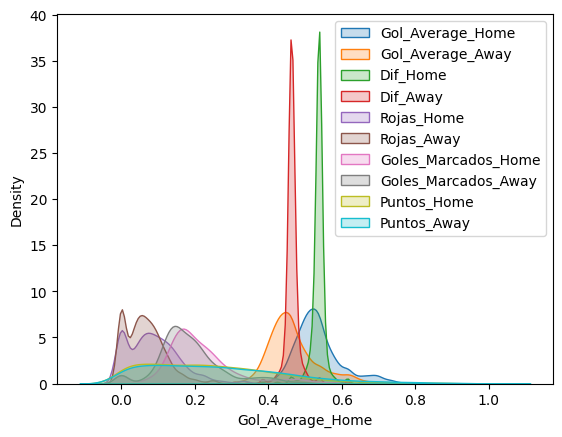

In [60]:
for i, col in enumerate(features_normalized_dataframe.columns):
    sns.kdeplot(features_normalized_dataframe[col], fill=True, label=columnas_features[i])
plt.legend()
plt.show()

In [61]:
onehot_encoder = OneHotEncoder(sparse_output=False)
equipos_encoded = onehot_encoder.fit_transform(np.array([equipos_locales, equipos_visitantes]).T)
equipos_encoded.shape

(4041, 68)

In [62]:
#predictores = np.concatenate([gol_average_home,gol_average_away,diferencia_home,diferencia_away,rojas_home,rojas_away], axis=1)
predictores = np.concatenate((features_normalized_dataframe[columnas_features].values, equipos_encoded), axis=1)

In [63]:
predictores.shape

(4041, 78)

## - Entrenamiento del modelo

### División del dataset en entrenamiento y evaluación del modelo

In [64]:
features_train, features_test, target_train, target_test = train_test_split( predictores, target, test_size=0.2, random_state=42)
print ('Train set:', features_train.shape,  target_train.shape)
print ('Test set:', features_test.shape,  target_test.shape)

Train set: (3232, 78) (3232,)
Test set: (809, 78) (809,)


### Definición y construcción del modelo

In [80]:
def get_modelo_regresion():
    model = LogisticRegression(max_iter=2000, solver='liblinear')
    return model

def get_modelo_random_forest():
    model = RandomForestClassifier(n_estimators=300, random_state=42, max_depth=13, criterion='log_loss')
    return model

def get_modelo_svc():
    model = SVC(kernel='linear', C=0.5, gamma='scale', probability=True)
    return model

def get_modelo_gbm(): ##mejores resultados pero tarda en entrenar
    model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)  
    return model

def get_modelo_decision_tree():
    model = DecisionTreeClassifier(criterion="log_loss",max_depth=13, random_state=42) 
    return model

def get_modelo_knn(): ##mejor recall en empates
    model = KNeighborsClassifier(n_neighbors=15, metric="manhattan")
    return model

def get_modelo_naive_bayes():
    #model = GaussianNB()
    model = MultinomialNB()
    return model

model = get_modelo_random_forest()

### Entrenamiento del modelo

In [81]:
model.fit(features_train, target_train)
#iteraciones=4
#historial_entrenamiento=model.fit(features_train, target_train, validation_data=(features_test,target_test), epochs=iteraciones, verbose=1)

RandomForestClassifier(criterion='log_loss', max_depth=10, n_estimators=300,
                       random_state=42)

## -Evaluación del modelo

### Evolución del modelo

In [82]:
target_pred = model.predict(features_test)
accuracy = accuracy_score(target_test, target_pred)
recal = recall_score(target_test, target_pred, average=None)
recal_total = recall_score(target_test, target_pred, average='macro')
precision = precision_score(target_test, target_pred, average=None)
precision_total = precision_score(target_test, target_pred, average='macro')
conf_matrix = confusion_matrix(target_test, target_pred)
print("Accuracy del modelo:", accuracy)
print("Recall del modelo:", recal)
print("Recall del modelo:", recal_total)
print("Precision del modelo:", precision)
print("Precision del modelo:", precision_total)
print("Matriz de Confusión:")
print(conf_matrix)

Accuracy del modelo: 0.4684796044499382
Recall del modelo: [0.45487365 0.26829268 0.71836735]
Recall del modelo: 0.48051122535833035
Precision del modelo: [0.52941176 0.4502924  0.44      ]
Precision del modelo: 0.47323472078890033
Matriz de Confusión:
[[126  55  96]
 [ 82  77 128]
 [ 30  39 176]]


ValueError: The number of FixedLocator locations (85), usually from a call to set_ticks, does not match the number of labels (7).

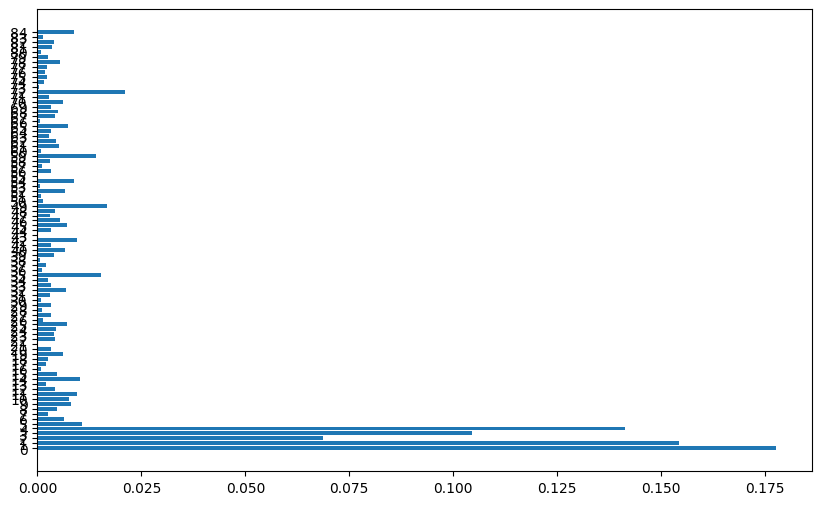

In [273]:
importances = model.feature_importances_

# Obtener nombres de las características
nombres_caracteristicas = ['GAH','GAA','RH','GH','GA','HT','AT']

# Crear un gráfico de barras para visualizar la importancia de las características
plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances, align='center')
plt.yticks(range(len(importances)), nombres_caracteristicas)
plt.xlabel('Importancia de las características')
plt.ylabel('Características')
plt.title('Importancia de las características en Random Forest')
plt.show()

## - Predicción real de un partido

In [142]:
'''
HT='Barcelona'
AT='Malaga'
datos_partido_a_predecir=datos_partidos.loc[(datos_partidos['HomeTeam']==HT) & (datos_partidos['AwayTeam']==AT)]
print(datos_partido_a_predecir.shape)
print(datos_partido_a_predecir)
'''
HT='Real Madrid'
AT='Osasuna'
gol_average_home = dict_ultimo_gol_average_equipo[HT]
gol_average_away = dict_ultimo_gol_average_equipo[AT]
dif_home = dict_ultimas_diferencias_cada_equipo[HT]
dif_away = dict_ultimas_diferencias_cada_equipo[AT]
rojas_home = dict_ultimas_rojas_cada_equipo[HT]
rojas_away = dict_ultimas_rojas_cada_equipo[AT]

### Normalizar los predictores teniendo en cuenta los predictores usados para el entrenamiento del modelo

In [143]:
local = [HT,]
visitante = [AT,]
locales_encoded = label_encoder.transform(local)
visitantes_encoded = label_encoder.transform(visitante)

equipos_encoded = onehot_encoder.transform(np.array([locales_encoded, visitantes_encoded]).T)
equipos_encoded.shape

(1, 80)

In [144]:
datos_partido = np.array([
    gol_average_home, gol_average_away,
    dif_home, dif_away,
    rojas_home, rojas_away
]).reshape(1, -1)
datos_partido = scale.transform(datos_partido)
datos_partido.shape

c:\Users\User\OneDrive\Escritorio\Cosas_TFG\.venv\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


(1, 6)

In [145]:
predictores = np.concatenate((datos_partido, equipos_encoded), axis=1)
predictores.shape

(1, 86)

### Predicción del valor objetivo

In [146]:
pred1 = model.predict_proba(predictores)
pred1

array([[0.12339029, 0.19494218, 0.68166753]])

### Conversión del número devuelto
Puede que el valor de las probabilidades devuelto por el modelo sea muy pequeño así que se opera para ser un número más manejable

In [147]:
def convertir_numbero(prediccion: list) -> list:
    prediccion_valores=[]
    for i in range(len(prediccion[0])):
      pred_number=float(format(prediccion[0][i], '.3f'))
      prediccion_valores.append(pred_number)

    return (prediccion_valores)
  
pred1_number_probabilities=convertir_numbero(pred1)

### Obtención del resultado predicho en base a las probabilidades predichas por el modelo

In [148]:
def get_ganador_prediccion(ganador: list) -> str:
    y=ganador.index(max(ganador))
    if y==0:
        pred_winner='Away'
    elif y==1:
        pred_winner='Draw'
    else:
        pred_winner='Home'
    return pred_winner

ganador_predicho=get_ganador_prediccion(pred1_number_probabilities)

### Resultado Final

In [149]:
#print('El ganador real es: ', ganador_real)
print('El ganador predicho es: ',ganador_predicho)

El ganador predicho es:  Home


### Visualización de las probabilidades en una gráfica

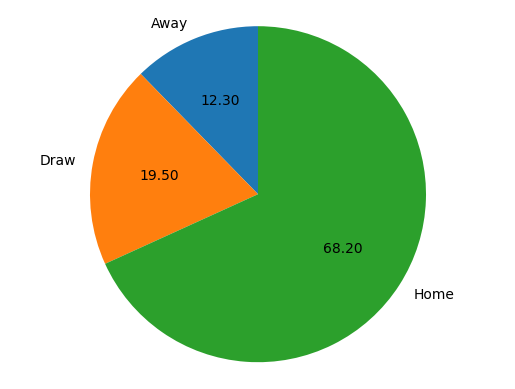

In [150]:
etiquetas = 'Away', 'Draw', 'Home'
figureObject, axesObject = plt.subplots()
axesObject.pie(pred1_number_probabilities, labels=etiquetas, autopct='%1.2f', startangle=90)
axesObject.axis('equal') # Aspect ratio equal means pie is a circle
plt.show()